# Notebook 03 — Train & Evaluate
## STOP 7 — Model Architecture
Define ANN with BatchNorm + Dropout + Sigmoid output.

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    balanced_accuracy_score,
    matthews_corrcoef,
    average_precision_score,
    precision_recall_curve,
    brier_score_loss,
)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
ARTIFACTS = ROOT / 'data' / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True, parents=True)
MODELS = ROOT / 'models'
CHARTS = ROOT / 'charts'
MODELS.mkdir(exist_ok=True, parents=True)
CHARTS.mkdir(exist_ok=True, parents=True)

with open(ARTIFACTS / 'preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

df = pd.read_csv(ROOT / 'data' / 'raw' / 'heart.csv')
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease'].astype(np.float32)

from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = preprocessor.transform(X_train_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(dtype=np.float32)).unsqueeze(1)
y_test_t = torch.tensor(y_test.to_numpy(dtype=np.float32)).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

class HeartANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

model = HeartANN(X_train.shape[1])
print(model)

HeartANN(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
    (12): Sigmoid()
  )
)


## STOP 8 — Weight Initialization
Apply Kaiming initialization on linear layers.

In [2]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        nn.init.constant_(m.bias, 0.0)

model.apply(init_weights)

HeartANN(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
    (12): Sigmoid()
  )
)

## STOP 9 — Loss Function & Optimizer
Use BCELoss and Adam optimizer.

In [3]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## STOP 10 + STOP 11 — Training + Validation Loop
Train for 100 epochs and track train/val loss/accuracy.

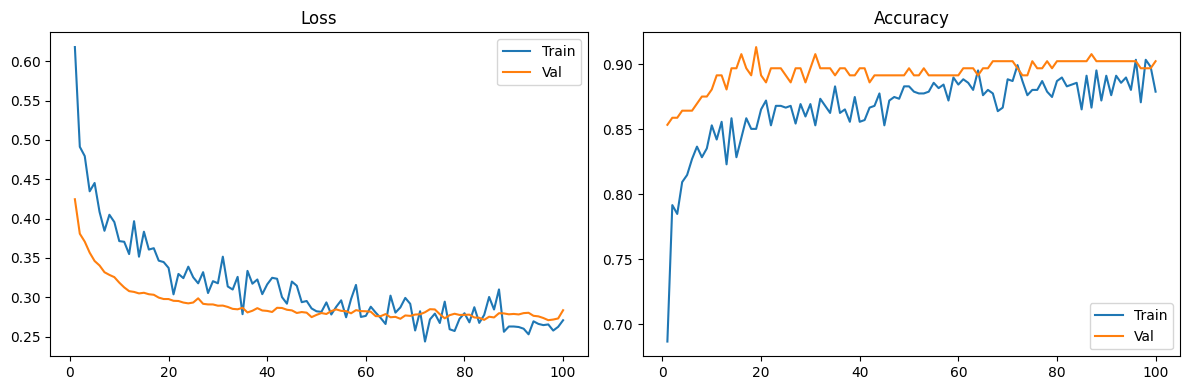

In [4]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(100):
    model.train()
    tr_loss = tr_correct = tr_total = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        prob = model(xb)
        loss = criterion(prob, yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * yb.size(0)
        tr_correct += ((prob >= 0.5).float() == yb).sum().item()
        tr_total += yb.size(0)

    model.eval()
    va_loss = va_correct = va_total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            prob = model(xb)
            loss = criterion(prob, yb)
            va_loss += loss.item() * yb.size(0)
            va_correct += ((prob >= 0.5).float() == yb).sum().item()
            va_total += yb.size(0)

    history['train_loss'].append(tr_loss / tr_total)
    history['train_acc'].append(tr_correct / tr_total)
    history['val_loss'].append(va_loss / va_total)
    history['val_acc'].append(va_correct / va_total)

x = np.arange(1, 101)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x, history['train_loss'], label='Train'); ax[0].plot(x, history['val_loss'], label='Val'); ax[0].legend(); ax[0].set_title('Loss')
ax[1].plot(x, history['train_acc'], label='Train'); ax[1].plot(x, history['val_acc'], label='Val'); ax[1].legend(); ax[1].set_title('Accuracy')
plt.tight_layout(); plt.savefig(CHARTS / 'training_curves.png', dpi=180); plt.show()

## STOP 12 — Evaluation Metrics
Compute accuracy, precision, recall, F1, ROC-AUC and plot confusion matrix + ROC.

Primary metrics:
{
  "accuracy": 0.9021739130434783,
  "precision": 0.8888888888888888,
  "recall": 0.9411764705882353,
  "f1": 0.9142857142857143,
  "roc_auc": 0.9476327116212339,
  "specificity": 0.8536585365853658,
  "npv": 0.9210526315789473,
  "balanced_accuracy": 0.8974175035868006,
  "mcc": 0.8023527118613422,
  "pr_auc": 0.9493884171688886,
  "brier_score": 0.08084480658723575
}
Threshold comparison:
   threshold  precision    recall        f1
0        0.3   0.852174  0.960784  0.903226
1        0.4   0.881818  0.950980  0.915094
2        0.5   0.888889  0.941176  0.914286
3        0.6   0.901961  0.901961  0.901961
4        0.7   0.901099  0.803922  0.849741


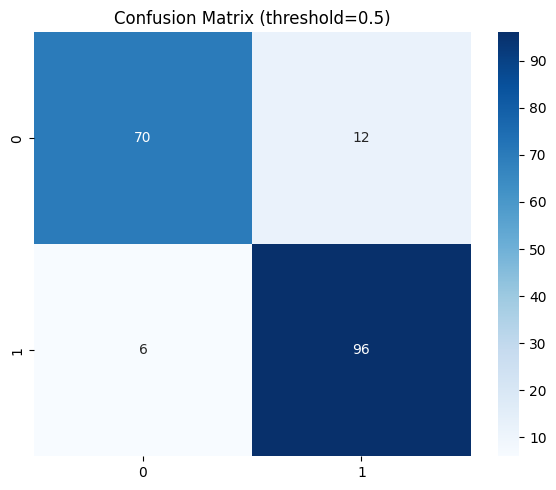

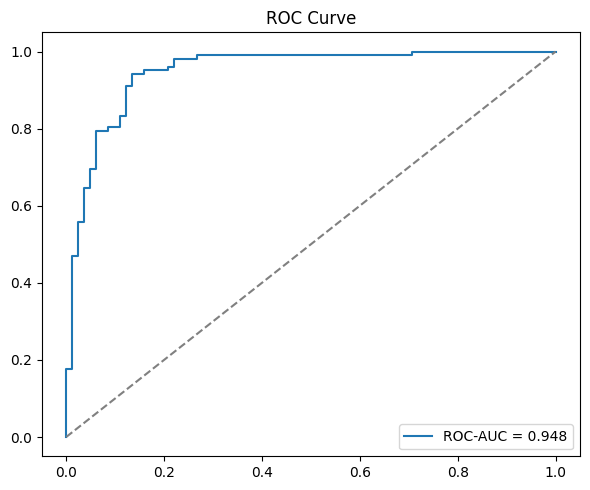

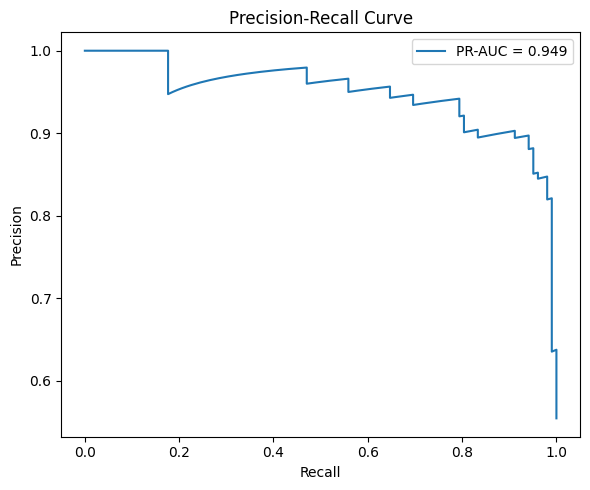

In [6]:
model.eval()
with torch.no_grad():
    probs = model(X_test_t).numpy().reshape(-1)

preds = (probs >= 0.5).astype(int)
y_true = y_test.to_numpy().astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

metrics = {
    'accuracy': float(accuracy_score(y_true, preds)),
    'precision': float(precision_score(y_true, preds)),
    'recall': float(recall_score(y_true, preds)),
    'f1': float(f1_score(y_true, preds)),
    'roc_auc': float(roc_auc_score(y_true, probs)),
    'specificity': float(tn / (tn + fp) if (tn + fp) else 0.0),
    'npv': float(tn / (tn + fn) if (tn + fn) else 0.0),
    'balanced_accuracy': float(balanced_accuracy_score(y_true, preds)),
    'mcc': float(matthews_corrcoef(y_true, preds)),
    'pr_auc': float(average_precision_score(y_true, probs)),
    'brier_score': float(brier_score_loss(y_true, probs)),
}

print('Primary metrics:')
print(json.dumps(metrics, indent=2))

threshold_rows = []
for th in [0.30, 0.40, 0.50, 0.60, 0.70]:
    th_pred = (probs >= th).astype(int)
    threshold_rows.append({
        'threshold': th,
        'precision': precision_score(y_true, th_pred, zero_division=0),
        'recall': recall_score(y_true, th_pred, zero_division=0),
        'f1': f1_score(y_true, th_pred, zero_division=0),
    })

print('Threshold comparison:')
print(pd.DataFrame(threshold_rows))

cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (threshold=0.5)')
plt.tight_layout()
plt.savefig(CHARTS / 'confusion_matrix.png', dpi=180)
plt.show()

fpr, tpr, _ = roc_curve(y_true, probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(CHARTS / 'roc_curve.png', dpi=180)
plt.show()

p_vals, r_vals, _ = precision_recall_curve(y_true, probs)
plt.figure(figsize=(6, 5))
plt.plot(r_vals, p_vals, label=f"PR-AUC = {metrics['pr_auc']:.3f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig(CHARTS / 'precision_recall_curve.png', dpi=180)
plt.show()

## Metric Guide (When to Use What)

- **Accuracy**: overall correctness. Good when classes are balanced; can be misleading on imbalanced data.
- **Precision**: "when model predicts positive, how often is it correct?" Use when false positives are expensive.
- **Recall (Sensitivity)**: "of all true positives, how many did we catch?" Use when false negatives are dangerous.
- **F1-score**: balance of precision and recall. Use when you need a single score under imbalance.
- **ROC-AUC**: ranking quality across thresholds. Useful for comparing models independent of one fixed threshold.
- **PR-AUC**: more informative than ROC-AUC when positive class is rare.
- **Specificity (TNR)**: ability to correctly identify negatives.
- **NPV**: when prediction is negative, probability it is truly negative.
- **Balanced Accuracy**: average of recall and specificity; robust to class imbalance.
- **MCC**: strong single-score metric that uses all four confusion-matrix values.
- **Brier Score**: probability calibration error. **Lower is better**.

### High vs Low
- Most metrics: **higher is better**.
- Brier score: **lower is better**.

### Precision vs Recall
- Precision-first: false positives are expensive.
- Recall-first: missing positives is expensive/dangerous.


## STOP 13 — Save Model
Save model state_dict and metrics/training history files.

In [7]:
torch.save(model.state_dict(), MODELS / 'model.pkl')
(ARTIFACTS / 'training_history.json').write_text(json.dumps(history, indent=2))
(MODELS / 'results.json').write_text(json.dumps(metrics, indent=2))
print('saved model and metrics artifacts')

saved model and metrics artifacts
